In [1]:
import sys
from pathlib import Path

THERMOIFT_SRC = Path("../thermoift/src").resolve()
if str(THERMOIFT_SRC) not in sys.path:
    sys.path.insert(0, str(THERMOIFT_SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import AutoMinorLocator
from thermoift import PLOT_SETTINGS as ps

In [2]:
df = pd.read_csv("../interfacial_results_dataset_A4.csv")

z_cols = [c for c in df.columns if c.startswith('z_')]

# Active-component threshold. Lowered from 1e-3 to 1e-7 so Dirichlet trace
# contributors (e.g. src 95's H2S = 3.9e-7) count as active. The downstream
# PC-SAFT solver (CompositionHandler.reduce_components) uses np.isclose with
# atol=1e-8, so anything > 1e-7 is genuinely included in the EOS.
ACTIVE_TH = 1e-7

# ── Component count per source (z > ACTIVE_TH) ──────────────────────────
first_rows = df.drop_duplicates('source_id').set_index('source_id')
n_comp = first_rows[z_cols].apply(lambda r: (r > ACTIVE_TH).sum(), axis=1)
print(f"Component count distribution (cutoff = {ACTIVE_TH:.0e}): "
      f"{n_comp.value_counts().sort_index().to_dict()}")
print(f"Max n_comp at this cutoff: {n_comp.max()}\n")

# ── Manually selected sources: one per complexity tier ──────────────────
# Selection criteria: distinct n_components and (where possible) distinct CO2
# fractions, then maximise P_bubble spread at 220 K.
#   src 89 : 2-comp  CO2=0.97  CO2+CO                                  P_bub(220K) =  15.6 MPa
#   src 21 : 4-comp  CO2=0.95  CO2+H2+CH4+H2S                          P_bub(220K) = 109.5 MPa
#   src 13 : 6-comp  CO2=0.98  CO2+H2+N2+Ar+CH4+O2                     P_bub(220K) =  29.2 MPa
#   src 48 : 7-comp  CO2=0.96  CO2+H2+N2+CH4+O2+CO+H2S                 P_bub(220K) =  33.3 MPa
#   src 95 : 8-comp  CO2=0.97  CO2+H2+N2+Ar+CH4+O2+CO+H2S (traces)     P_bub(220K) =  37.1 MPa
# Note: CO2=0.97 appears in both src 89 and src 95. The dataset contains no
# 8-component source at any other CO2 fraction above ACTIVE_TH = 1e-7.
top_ids = [89, 21, 13, 48, 95]

# ── Composition labels (non-CO2 components) ─────────────────────────────
_comp_tex = {
    'hydrogen':         r'\mathrm{H_2}',
    'argon':            r'\mathrm{Ar}',
    'nitrogen':         r'\mathrm{N_2}',
    'methane':          r'\mathrm{CH_4}',
    'oxygen':           r'\mathrm{O_2}',
    'carbon monoxide':  r'\mathrm{CO}',
    'hydrogen sulfide': r'\mathrm{H_2S}',
}

def source_label(sid):
    row = first_rows.loc[sid]
    parts = [r'\mathrm{CO_2}']
    for comp, tex in _comp_tex.items():
        col = f'z_{comp}'
        if col in first_rows.columns and row[col] > ACTIVE_TH:
            parts.append(tex)
    return r'$' + '+'.join(parts) + r'$'

COLORS = ps.color_10[:len(top_ids)]
labels = {sid: source_label(sid) for sid in top_ids}

print("Selected sources:")
pb220 = df[df['temperature'].between(219.9, 220.1)].drop_duplicates('source_id').set_index('source_id')['P_bubble']
for sid in top_ids:
    print(f"  src {sid:3d}  n_comp={n_comp[sid]}  P_bub(220K)={pb220[sid]:.1f} MPa  {labels[sid]}")

Component count distribution (cutoff = 1e-07): {2: 6, 3: 26, 4: 21, 5: 21, 6: 13, 7: 6, 8: 7}
Max n_comp at this cutoff: 8

Selected sources:
  src  89  n_comp=2  P_bub(220K)=15.6 MPa  $\mathrm{CO_2}+\mathrm{CO}$
  src  21  n_comp=4  P_bub(220K)=109.5 MPa  $\mathrm{CO_2}+\mathrm{H_2}+\mathrm{CH_4}+\mathrm{H_2S}$
  src  13  n_comp=6  P_bub(220K)=29.2 MPa  $\mathrm{CO_2}+\mathrm{H_2}+\mathrm{Ar}+\mathrm{N_2}+\mathrm{CH_4}+\mathrm{O_2}$
  src  48  n_comp=7  P_bub(220K)=33.3 MPa  $\mathrm{CO_2}+\mathrm{H_2}+\mathrm{N_2}+\mathrm{CH_4}+\mathrm{O_2}+\mathrm{CO}+\mathrm{H_2S}$
  src  95  n_comp=8  P_bub(220K)=37.1 MPa  $\mathrm{CO_2}+\mathrm{H_2}+\mathrm{Ar}+\mathrm{N_2}+\mathrm{CH_4}+\mathrm{O_2}+\mathrm{CO}+\mathrm{H_2S}$


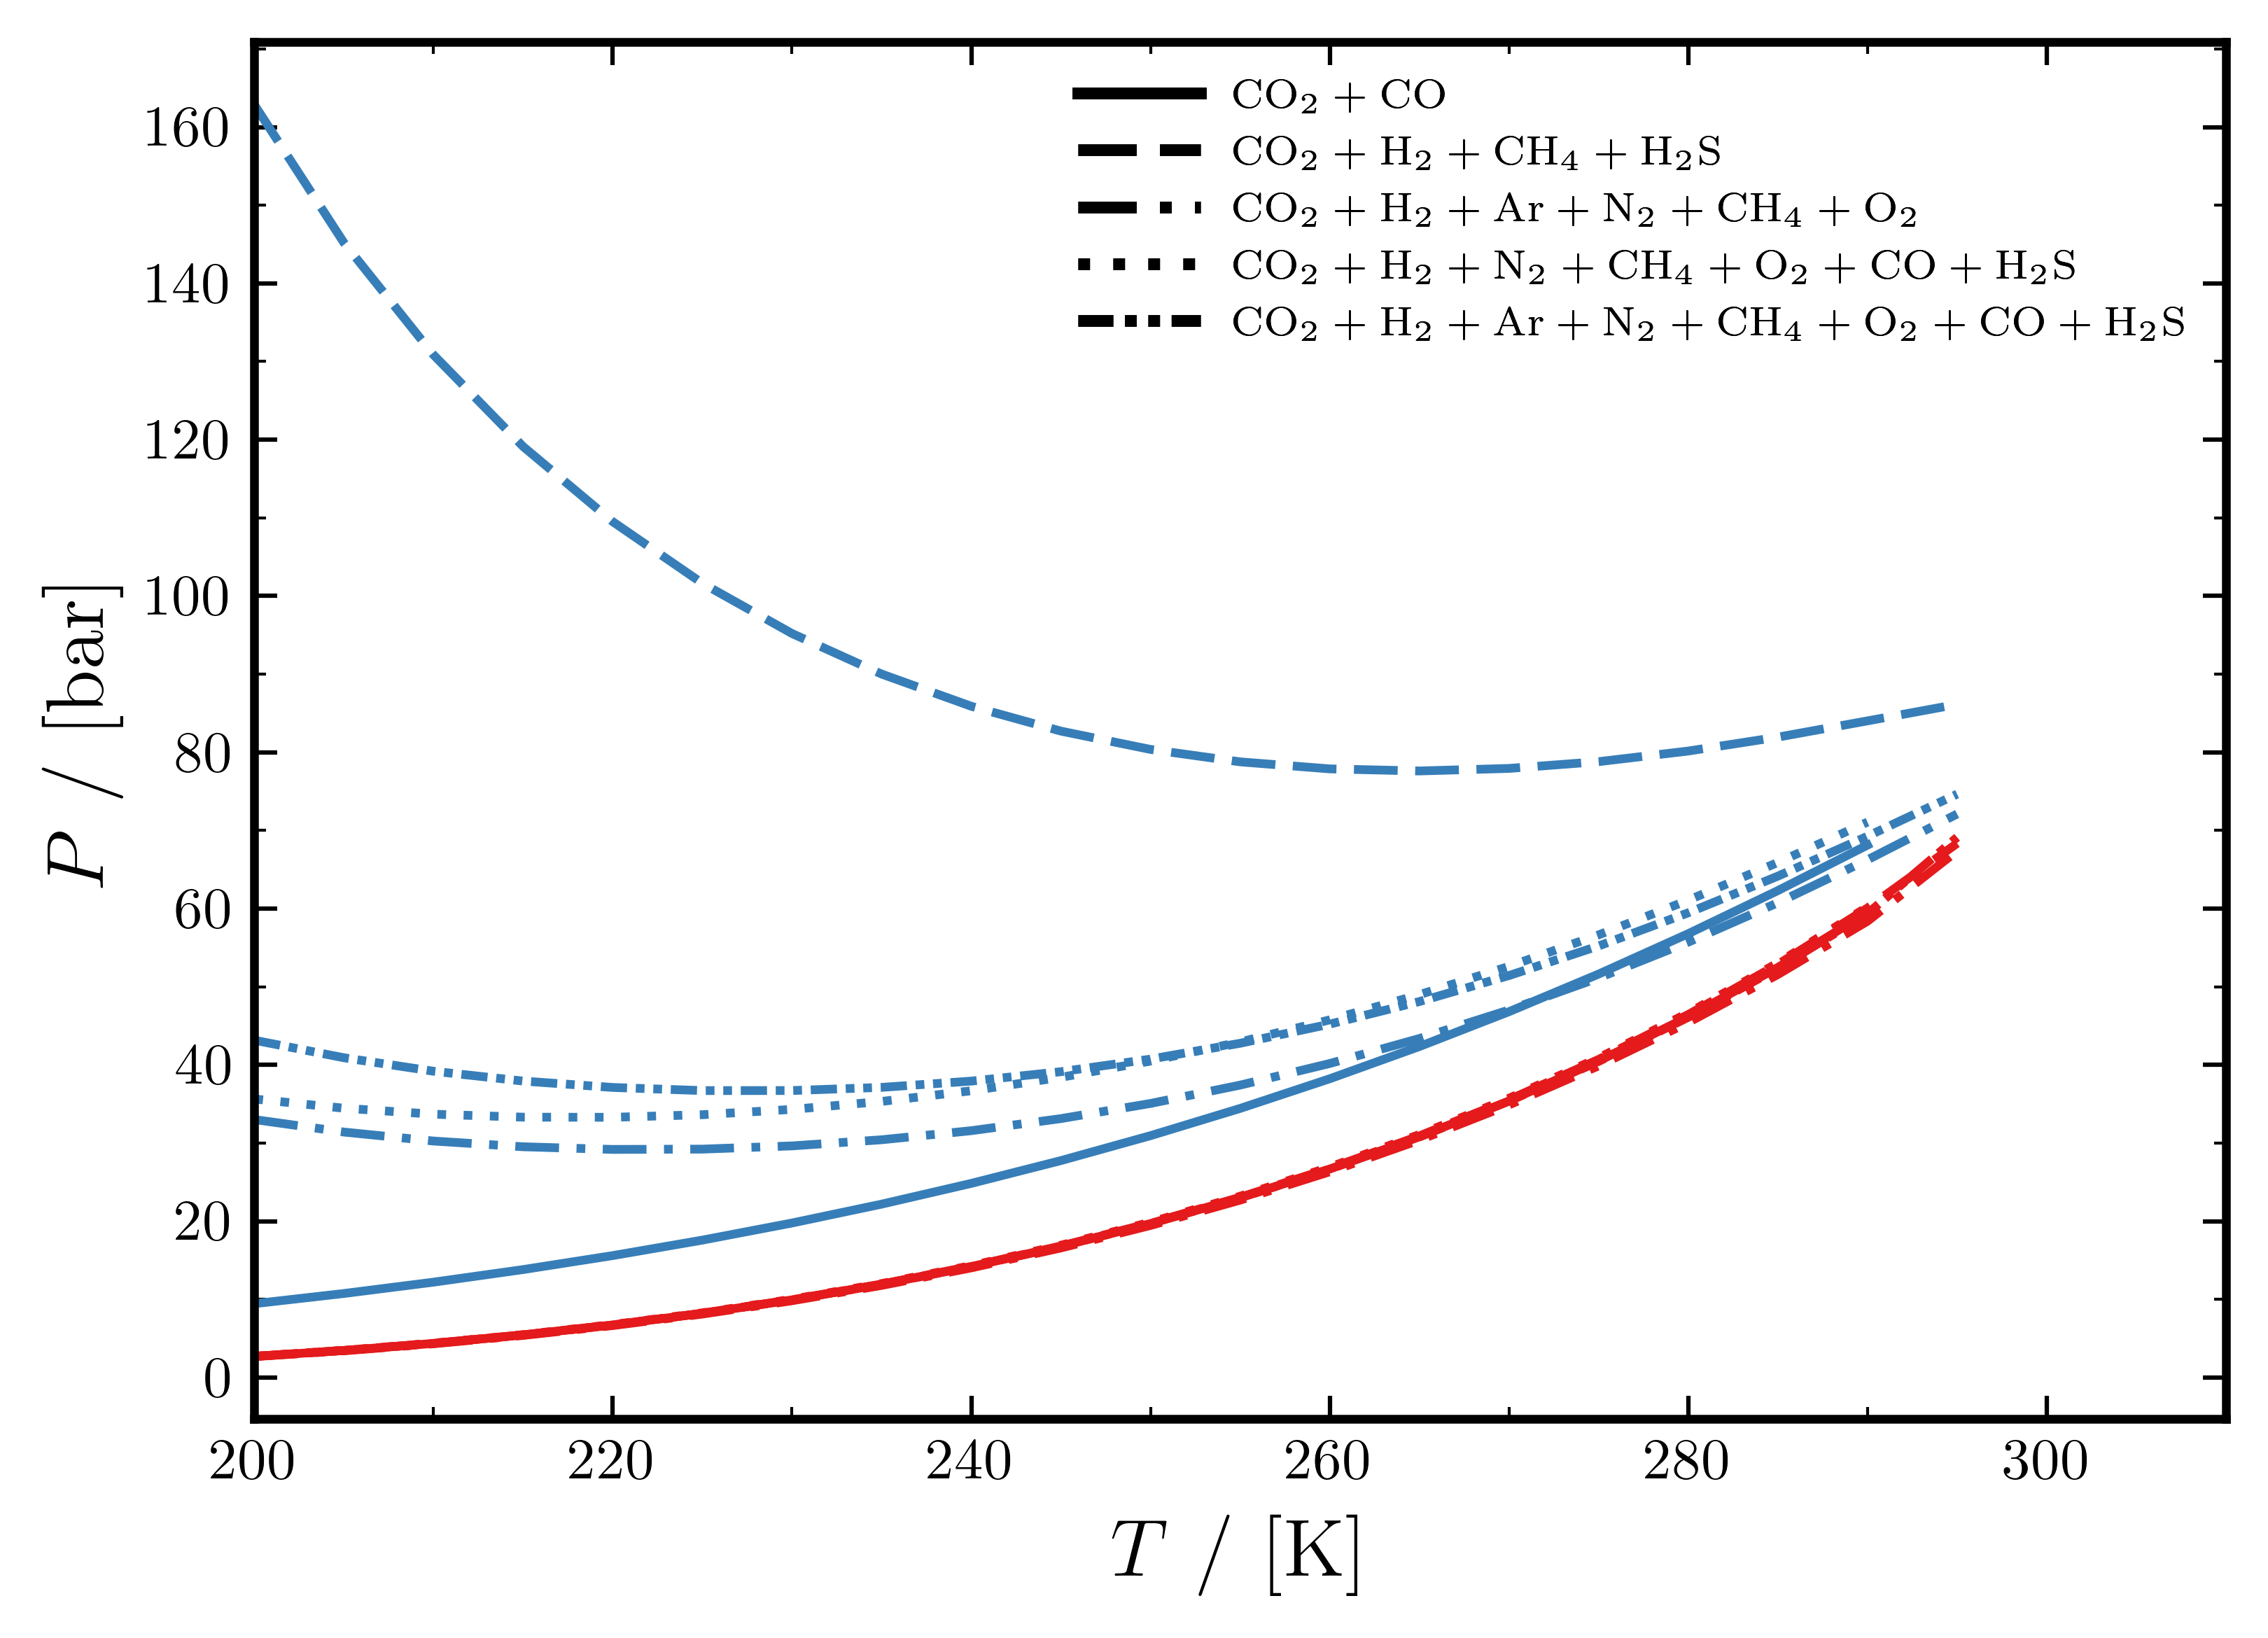

In [3]:
# ── Plot 1: PT Phase Map ────────────────────────────────────────────────
# Blue = bubble, Red = dew; line style differentiates source

LINE_STYLES = [
    '-',
    (0, (5, 2)),               # dashed   — tighter than '--'
    (0, (5, 2, 1, 2)),         # dash-dot — tighter than '-.'
    (0, (1, 2)),               # dotted   — tighter than ':'
    (0, (3, 1, 1, 1, 1, 1)),   # dash-dot-dot — for the 8-component source
]

envelope = (
    df[df['source_id'].isin(top_ids)]
    .drop_duplicates(subset=['source_id', 'temperature'])
    .sort_values(['source_id', 'temperature'])
)

fig, ax = ps.plot_init(w=5.5, h=4.0)

for sid, ls in zip(top_ids, LINE_STYLES):
    sub = envelope[envelope['source_id'] == sid].sort_values('temperature')
    ax.plot(sub['temperature'], sub['P_bubble'], color='#377eb8', lw=1.5, ls=ls)
    ax.plot(sub['temperature'], sub['P_dew'],    color='#e41a1c', lw=1.5, ls=ls)

# Source legend: black handles, one per line style
src_handles = [
    mlines.Line2D([], [], color='black', lw=2.0, ls=ls, label=labels[sid])
    for sid, ls in zip(top_ids, LINE_STYLES)
]
leg_src = ax.legend(handles=src_handles, fontsize=7, loc='upper right',
                    frameon=False, handlelength=3.0)
ax.add_artist(leg_src)

# Color legend: bubble / dew (lower right)
h_bub = mlines.Line2D([], [], color='#377eb8', lw=2.0, ls='-', label='bubble')
h_dew = mlines.Line2D([], [], color='#e41a1c', lw=2.0, ls='-', label='dew')
# ax.legend(handles=[h_bub, h_dew], fontsize=7, loc='lower right',
#           frameon=False, handlelength=3.0)

ax.set_xlabel(r'$T$ $/$ $[\mathrm{K}]$',   fontsize=ps.label_fontsize)
ax.set_ylabel(r'$P$ $/$ $[\mathrm{bar}]$', fontsize=ps.label_fontsize)

ps.apply_axis_style(ax)
ax.tick_params(axis='both', which='major', bottom=True, top=True,
               left=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

plt.xlim(200, 310)
plt.tight_layout()
ps.save_plot(fig, 'sensitivity_PT_phase_map')
plt.show()

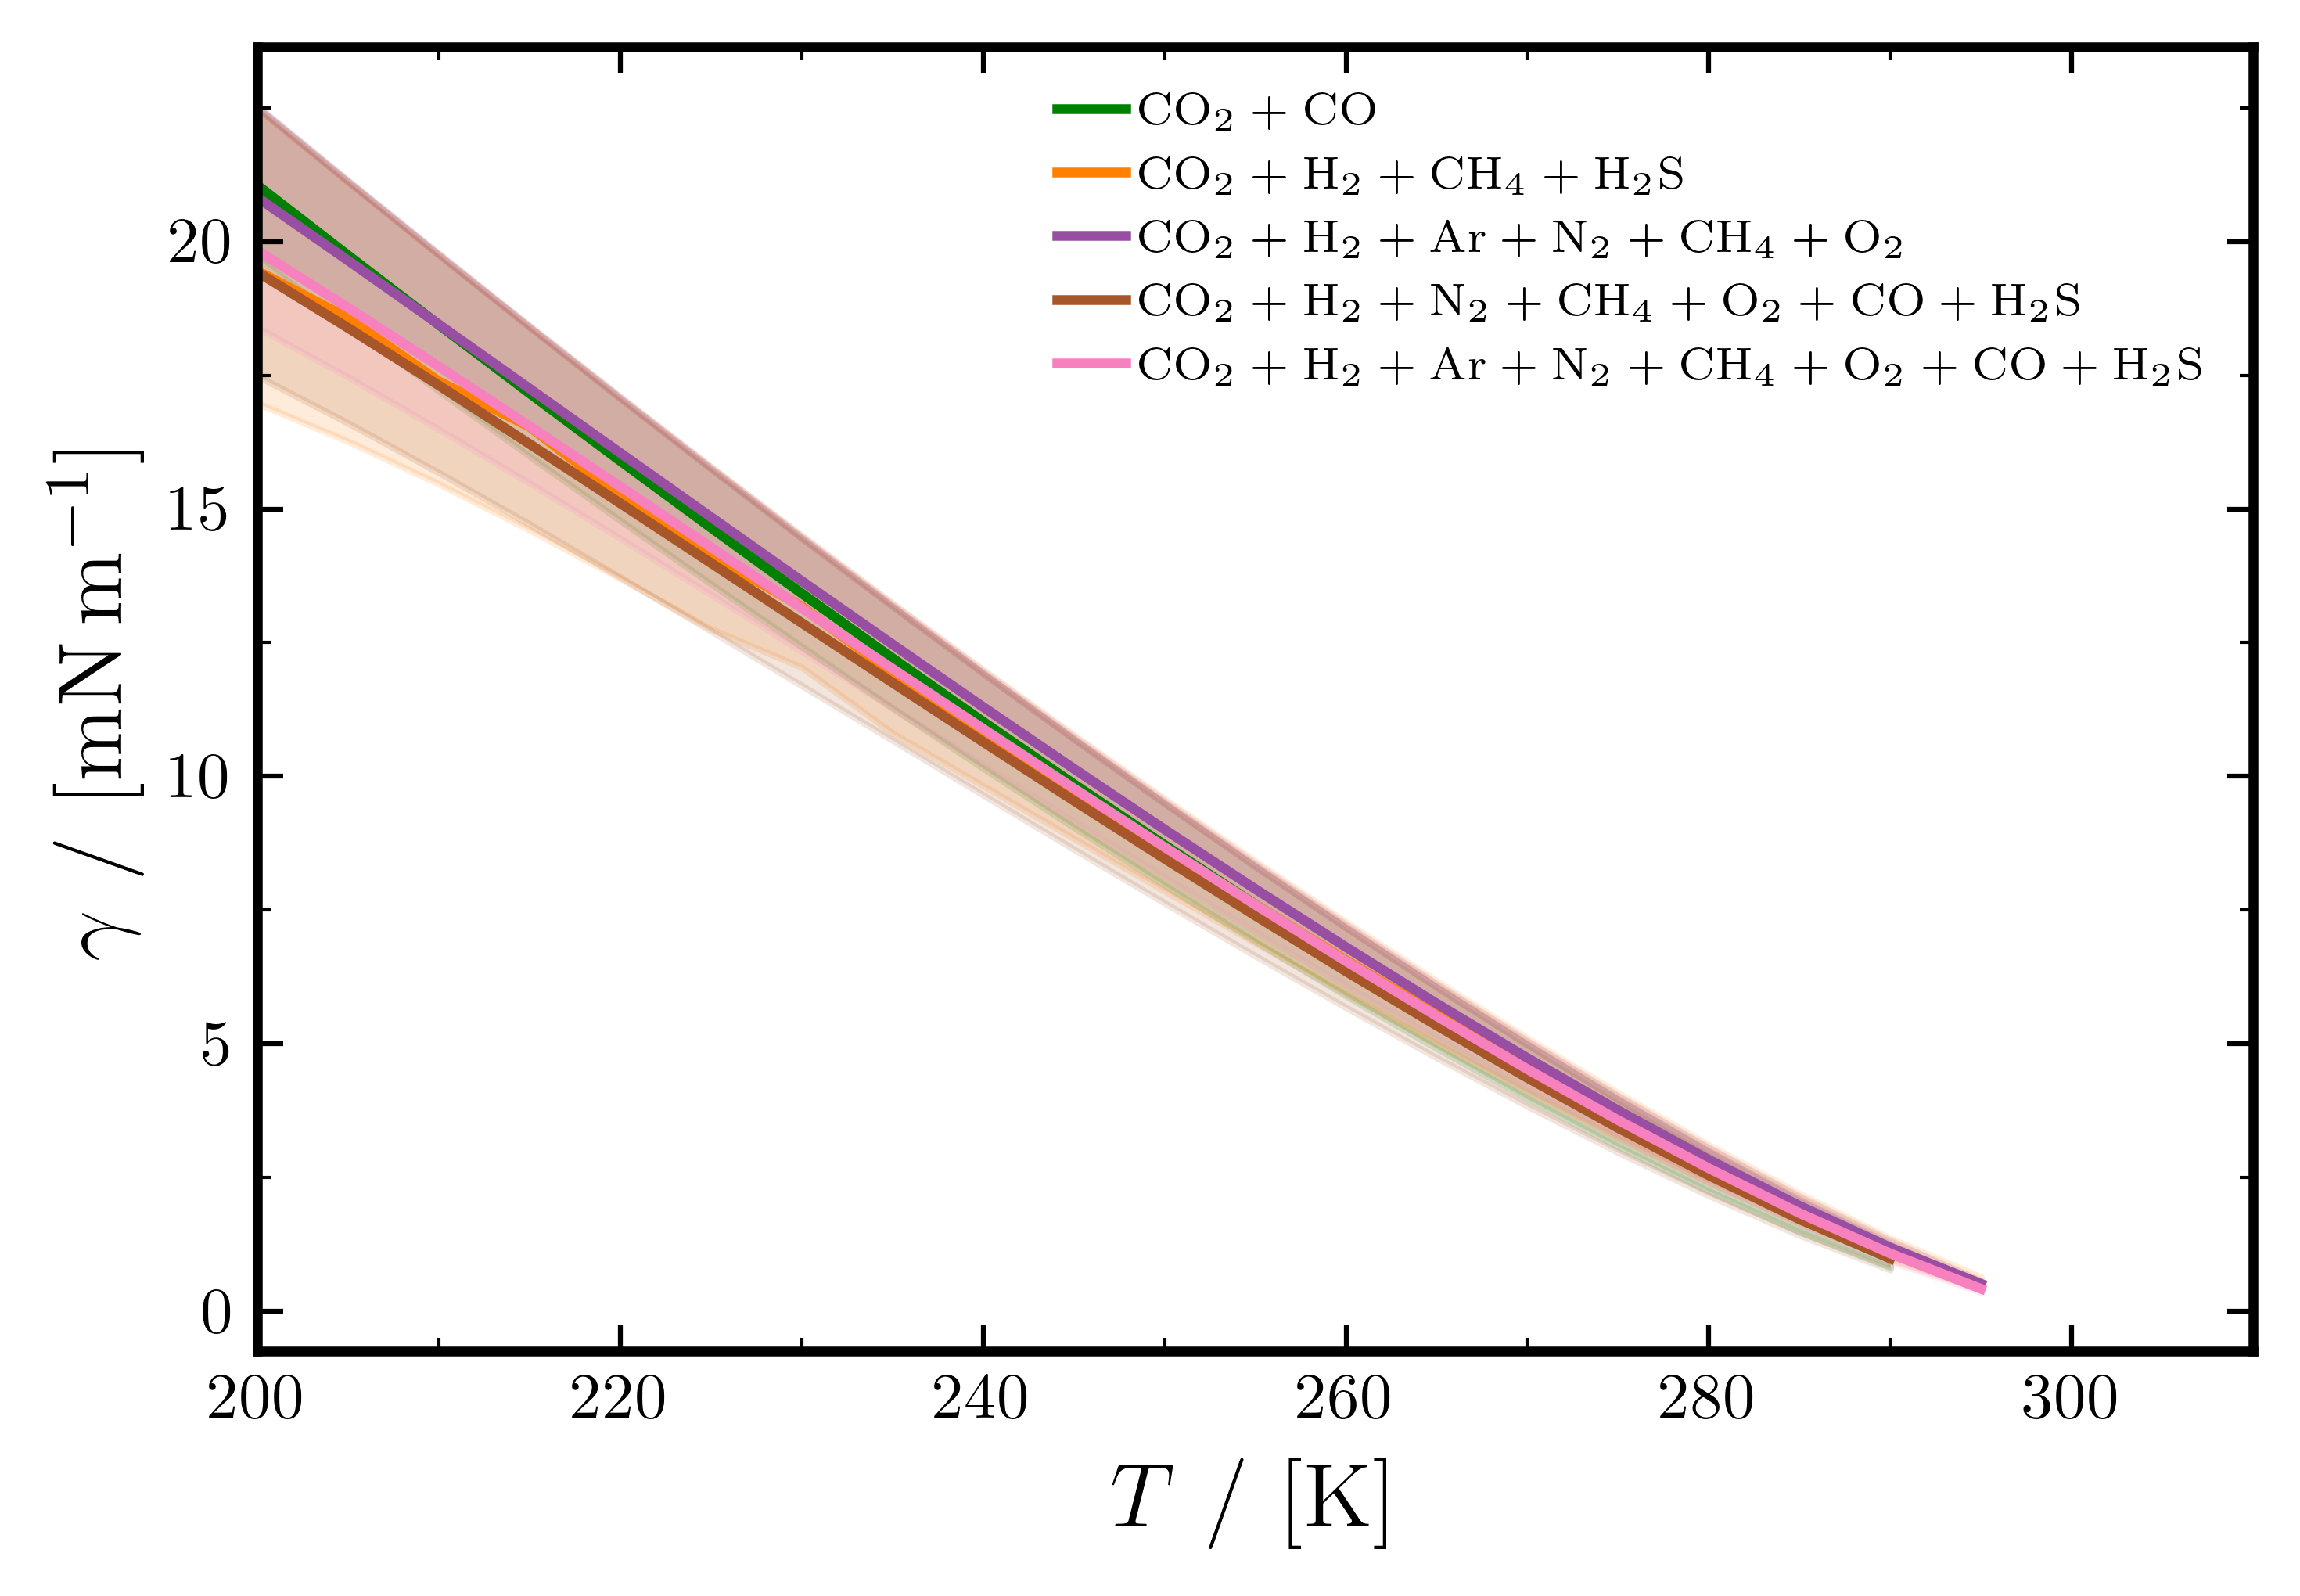

In [4]:
fig, ax = ps.plot_init(w=5.0, h=3.5)

for sid, color in zip(top_ids, COLORS):
    sub  = df[df['source_id'] == sid]
    grp  = sub.groupby('temperature')['gamma']
    T_vals = sorted(sub['temperature'].unique())
    means  = [grp.get_group(T).mean() for T in T_vals]
    mins   = [grp.get_group(T).min()  for T in T_vals]
    maxs   = [grp.get_group(T).max()  for T in T_vals]

    ax.plot(T_vals, means, color=color, lw=1.5, ls='-', label=labels[sid])
    ax.fill_between(T_vals, mins, maxs, alpha=0.15, color=color)

ax.set_xlabel(r'$T$ $/$ $[\mathrm{K}]$',                       fontsize=ps.label_fontsize)
ax.set_ylabel(r'$\gamma$ $/$ $[\mathrm{mN\,m^{-1}}]$',       fontsize=ps.label_fontsize)

ps.apply_axis_style(ax)
ax.tick_params(axis='both', which='major', bottom=True, top=True,
               left=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

leg = ps.style_legend(ax, fontsize=7, ncol=1, loc='upper right', frame=False)

plt.xlim(200, 310)
plt.tight_layout()
ps.save_plot(fig, 'sensitivity_gamma_vs_T')
plt.show()

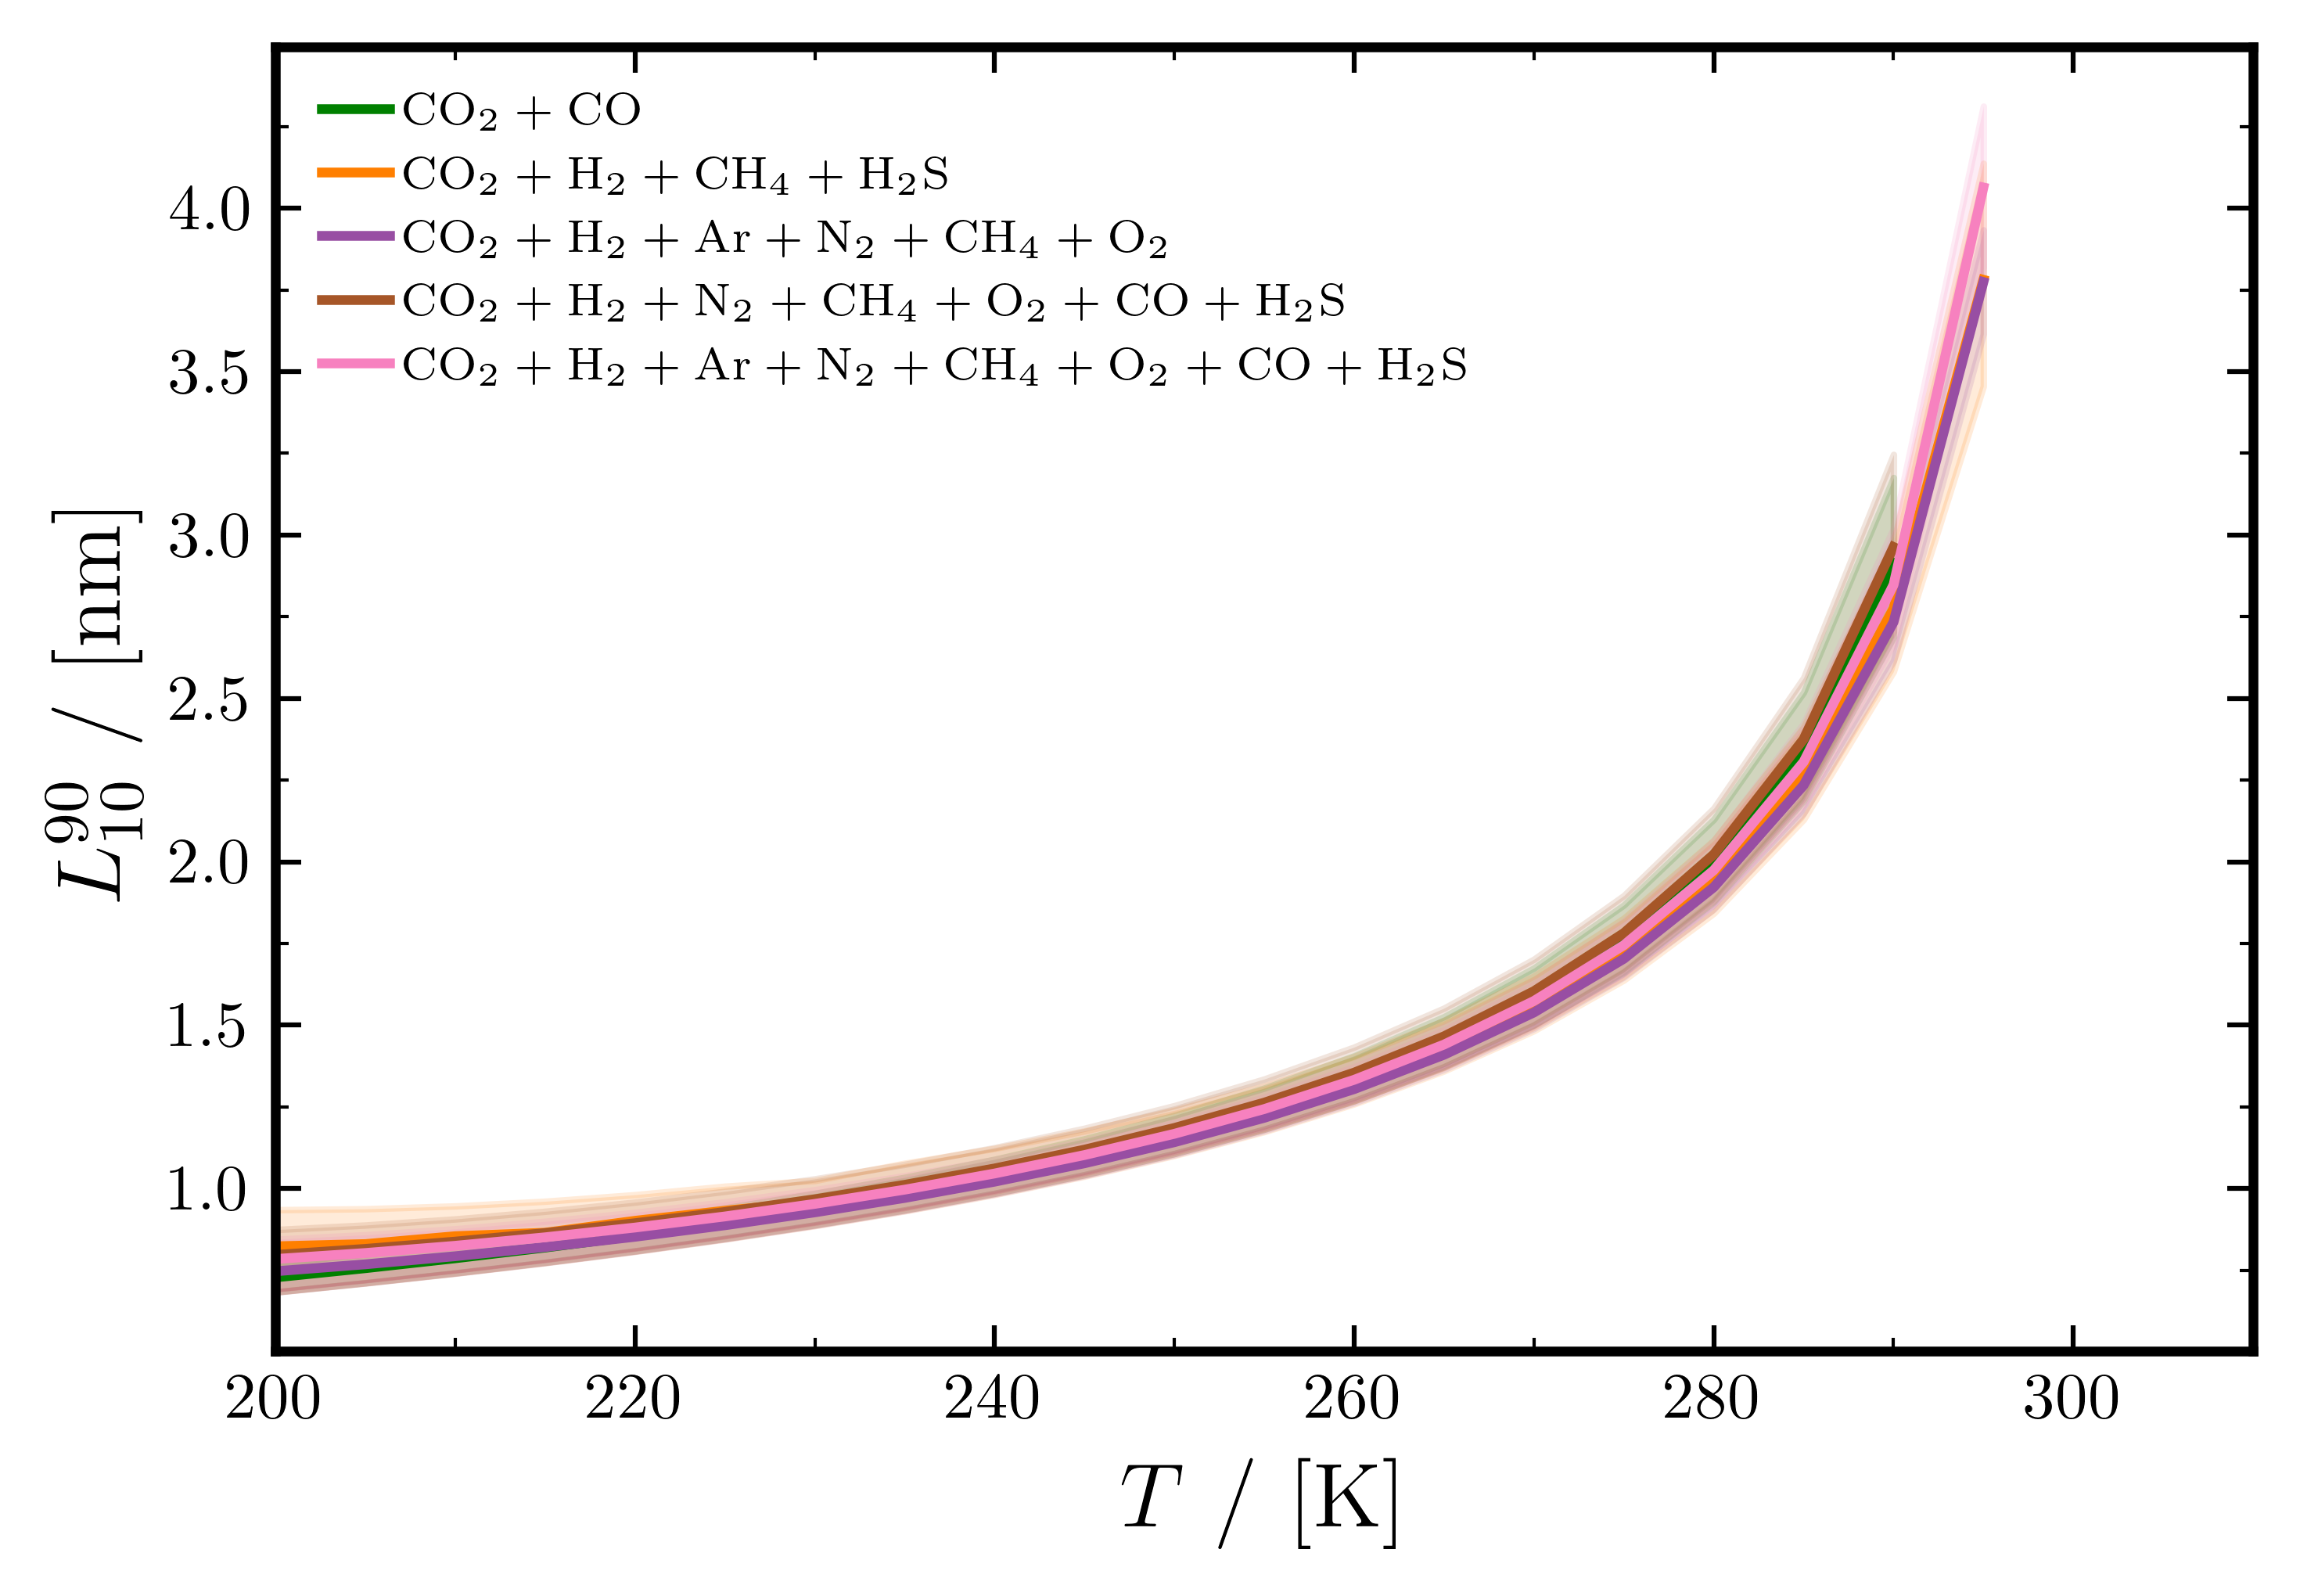

In [5]:
# ── Plot 3: Interfacial Thickness (L90_10) vs Temperature ──────────────

fig, ax = ps.plot_init(w=5.0, h=3.5)

for sid, color in zip(top_ids, COLORS):
    sub  = df[df['source_id'] == sid]
    grp  = sub.groupby('temperature')['interfacial_thickness']
    T_vals = sorted(sub['temperature'].unique())
    means  = [grp.get_group(T).mean() for T in T_vals]
    mins   = [grp.get_group(T).min()  for T in T_vals]
    maxs   = [grp.get_group(T).max()  for T in T_vals]

    ax.plot(T_vals, means, color=color, lw=1.5, ls='-', label=labels[sid])
    ax.fill_between(T_vals, mins, maxs, alpha=0.15, color=color)

ax.set_xlabel(r'$T$ $/$ $[\mathrm{K}]$',                fontsize=ps.label_fontsize)
ax.set_ylabel(r'$L^{90}_{10}$ $/$ $[\mathrm{nm}]$',     fontsize=ps.label_fontsize)

ps.apply_axis_style(ax)
ax.tick_params(axis='both', which='major', bottom=True, top=True,
               left=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

leg = ps.style_legend(ax, fontsize=7, ncol=1, loc='upper left', frame=False)

plt.xlim(200, 310)
plt.tight_layout()
ps.save_plot(fig, 'sensitivity_thickness_vs_T')
plt.show()

In [6]:
# ── Export feeds to CSV for VLE_IFT_V4.ipynb ───────────────────────────────
# Two kinds of feeds get written:
#   1. Dataset sources listed in top_ids (with their original compositions).
#   2. Synthetic feeds (SYNTHETIC_FEEDS), used when the dataset has no source
#      in a desired niche (e.g., 7-comp at CO2=0.96 with high P_bub). When a
#      synthetic feed has `replaces_dataset_id`, that dataset source is removed
#      from the CSV run set (but still appears in top_ids for plotting).
#
# The plots above (cells 2–4) iterate top_ids unchanged because they need
# envelope data from interfacial_results_dataset_A4.csv. Synthetic feeds have
# no precomputed envelope; their envelope is generated by running VLE_IFT_V4.
import os

# Synthetic 7-component composition at CO2=0.96, designed for P_bub(220K) in
# 50–100 bar (dataset has no 7-comp source in this niche; both src 9 and
# src 48 sit at ~30 bar). H2=0.020 was chosen from a PC-SAFT bubble-point
# sweep that predicted P_bub(220K) ≈ 75 bar.
SYNTHETIC_FEEDS = [
    {
        'name': 'synth_7comp_CO2_096_Pbub75',
        'replaces_dataset_id': 48,
        'z': {
            'CO2': 0.960, 'H2':  0.020, 'N2':  0.008, 'CH4': 0.004,
            'O2':  0.004, 'CO':  0.002, 'H2S': 0.002, 'Ar':  0.0,
        },
        'expected_P_bub_220K_bar': 75.4,
        'note': '7-comp (drops Ar) at CO2=0.96; H2-rich impurity pushes P_bub above src 48',
    },
]

_z_to_short = {
    'z_carbon dioxide':  'CO2', 'z_hydrogen':        'H2',
    'z_argon':           'Ar',  'z_nitrogen':        'N2',
    'z_methane':         'CH4', 'z_oxygen':          'O2',
    'z_carbon monoxide': 'CO',  'z_hydrogen sulfide':'H2S',
}
_short_order = ['CO2', 'H2', 'Ar', 'N2', 'CH4', 'O2', 'CO', 'H2S']

_replaced_ids = {f['replaces_dataset_id'] for f in SYNTHETIC_FEEDS
                 if f.get('replaces_dataset_id') is not None}

_rows = []
_run_order = []   # parallel list of (label, source_id_or_None) for the printout

for sid in top_ids:
    if sid in _replaced_ids:
        # Substitute the synthetic feed that targets this dataset id
        synth = next(f for f in SYNTHETIC_FEEDS if f.get('replaces_dataset_id') == sid)
        z = {s: float(synth['z'].get(s, 0.0)) for s in _short_order}
        # normalize to sum to 1
        _tot = sum(z.values())
        if _tot > 0:
            z = {k: v / _tot for k, v in z.items()}
        active = [c for c in _short_order if z[c] > ACTIVE_TH]
        _rows.append({
            'feed_source':       synth['name'],
            'template_name':     'synthetic_replaces_src_48',
            'mixture_size':      len(active),
            'active_components': ','.join(active),
            **{c: z[c] for c in _short_order},
        })
        _run_order.append((synth['name'], None,
                           f"synthetic (expected P_bub≈{synth['expected_P_bub_220K_bar']:.0f} bar)"))
        continue

    r = first_rows.loc[sid]
    z = {s: float(r[zcol]) for zcol, s in _z_to_short.items()}
    active = [c for c in _short_order if z[c] > ACTIVE_TH]
    _rows.append({
        'feed_source':       f'sensitivity_src_{sid}',
        'template_name':     'selected_diverse_Pbubble',
        'mixture_size':      len(active),
        'active_components': ','.join(active),
        **{c: z[c] for c in _short_order},
    })
    _run_order.append((f'src {sid}', sid, labels[sid]))

selected_df = pd.DataFrame(
    _rows,
    columns=['feed_source', 'template_name', 'mixture_size', 'active_components'] + _short_order,
)

os.makedirs('CSV_feeds', exist_ok=True)
_csv_main = 'CSV_feeds/Combined_compositions.csv'
_csv_copy = 'selected_sensitivity_compositions.csv'
selected_df.to_csv(_csv_main, index=False)
selected_df.to_csv(_csv_copy, index=False)

print(f"Wrote {len(selected_df)} feeds to:")
print(f"  {os.path.abspath(_csv_main)}")
print(f"  {os.path.abspath(_csv_copy)}")
print()
print("FEED_INDEX -> feed mapping for VLE_IFT_V4.ipynb:")
for i, (name, sid, label) in enumerate(_run_order):
    print(f"  FEED_INDEX={i}  {name:<32}  {label}")
selected_df

Wrote 5 feeds to:
  /home/darshan/A6/PCSAFT_cDFT/PART_1/SENSITIVITY_ANALYSIS/CSV_feeds/Combined_compositions.csv
  /home/darshan/A6/PCSAFT_cDFT/PART_1/SENSITIVITY_ANALYSIS/selected_sensitivity_compositions.csv

FEED_INDEX -> feed mapping for VLE_IFT_V4.ipynb:
  FEED_INDEX=0  src 89                            $\mathrm{CO_2}+\mathrm{CO}$
  FEED_INDEX=1  src 21                            $\mathrm{CO_2}+\mathrm{H_2}+\mathrm{CH_4}+\mathrm{H_2S}$
  FEED_INDEX=2  src 13                            $\mathrm{CO_2}+\mathrm{H_2}+\mathrm{Ar}+\mathrm{N_2}+\mathrm{CH_4}+\mathrm{O_2}$
  FEED_INDEX=3  synth_7comp_CO2_096_Pbub75        synthetic (expected P_bub≈75 bar)
  FEED_INDEX=4  src 95                            $\mathrm{CO_2}+\mathrm{H_2}+\mathrm{Ar}+\mathrm{N_2}+\mathrm{CH_4}+\mathrm{O_2}+\mathrm{CO}+\mathrm{H_2S}$


,feed_source,template_name,mixture_size,active_components,CO2,H2,Ar,N2,CH4,O2,CO,H2S
0,sensitivity_src_89,selected_diverse_Pbubble,2,"CO2,CO",0.97,0.000000,0.000000,0.000000,0.000000,0.000000,0.030000,0.000000e+00
1,sensitivity_src_21,selected_diverse_Pbubble,4,"CO2,H2,CH4,H2S",0.95,0.031349,0.000000,0.000000,0.003876,0.000000,0.000000,1.477475e-02
2,sensitivity_src_13,selected_diverse_Pbubble,6,"CO2,H2,Ar,N2,CH4,O2",0.98,0.005827,0.009104,0.001097,0.002880,0.001092,0.000000,0.000000e+00
3,synth_7comp_CO2_096_Pbub75,synthetic_replaces_src_48,7,"CO2,H2,N2,CH4,O2,CO,H2S",0.96,0.020000,0.000000,0.008000,0.004000,0.004000,0.002000,2.000000e-03
4,sensitivity_src_95,selected_diverse_Pbubble,8,"CO2,H2,Ar,N2,CH4,O2,CO,H2S",0.97,0.007463,0.003993,0.007901,0.009905,0.000038,0.000699,3.902590e-07
